# Data Challenge : Leukemia Risk Prediction

We load necessary Python libraries for data manipulation, preprocessing, modeling, and survival analysis.

In [ ]:
import numpy as np
import re
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler,MinMaxScaler

from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw

Load clinical, molecular, and target CSV files for training and testing.

In [130]:
# Clinical data
clinical_train = pd.read_csv("./X_train/clinical_train.csv")
clinical_test  = pd.read_csv("./X_test/clinical_test.csv")

# Molecular data
molecular_train = pd.read_csv("./X_train/molecular_train.csv")
molecular_test  = pd.read_csv("./X_test/molecular_test.csv")

# Targets
target = pd.read_csv("./target_train.csv")

In [131]:
print((molecular_train['END']-molecular_train['START']).value_counts())

0.0      7607
1.0      1933
2.0       310
4.0       242
23.0      123
3.0       101
5.0        90
24.0       65
8.0        46
7.0        36
6.0        33
15.0       30
14.0       22
13.0       21
10.0       16
11.0       16
16.0       15
17.0       14
52.0       11
9.0        10
19.0       10
12.0        7
18.0        6
20.0        5
26.0        5
22.0        4
21.0        4
55.0        3
37.0        3
28.0        3
25.0        3
38.0        3
58.0        2
32.0        2
41.0        2
59.0        2
62.0        1
56.0        1
575.0       1
27.0        1
75.0        1
34.0        1
69.0        1
35.0        1
70.0        1
43.0        1
44.0        1
29.0        1
33.0        1
46.0        1
31.0        1
30.0        1
Name: count, dtype: int64


Check for missing values in the target dataset and drop incomplete rows. Also display the distribution of survival events.

In [132]:
print(target.isnull().sum())
target = target.dropna(subset=["OS_STATUS", "OS_YEARS"])
print(len(target))
print(target["OS_STATUS"].value_counts())

ID             0
OS_YEARS     150
OS_STATUS    150
dtype: int64
3173
OS_STATUS
1.0    1600
0.0    1573
Name: count, dtype: int64


Aggregate molecular mutation data per patient:
- Count total and truncating mutations
- Mean and max variant allele fraction (VAF)
- High-impact mutations
- Earliest truncation position

In [133]:
def build_molecular_features(df):
    df = df.copy()

    # --- Protein-level features ---
    def is_truncating(s):
        if pd.isna(s):
            return 0
        return int("*" in s or "fs" in s)

    def stop_position(s):
        if pd.isna(s) or "*" not in s:
            return np.nan
        m = re.search(r"\d+", s)
        return int(m.group()) if m else np.nan

    df["TRUNCATING"] = df["PROTEIN_CHANGE"].apply(is_truncating)
    df["STOP_POS"] = df["PROTEIN_CHANGE"].apply(stop_position)

    agg = df.groupby("ID").agg(
        # Existing features
        N_MUT=("GENE", "count"),
        MEAN_VAF=("VAF", "mean"),
        MAX_VAF=("VAF", "max"),
        HIGH_IMPACT=("EFFECT", lambda x: x.isin([
            "PTD",
            "ITD",
            "stop_lost"
        ]).sum()),
        N_TRUNCATING=("TRUNCATING", "sum"),
        EARLIEST_TRUNC_POS=("STOP_POS", "min")
    ).reset_index()

    return agg
mol_train_feat = build_molecular_features(molecular_train)
mol_test_feat  = build_molecular_features(molecular_test)

Combine engineered molecular features with clinical features for modeling. Fill missing molecular values (patients without mutations).

In [134]:
train_df = clinical_train.merge(mol_train_feat, on="ID", how="left")
test_df  = clinical_test.merge(mol_test_feat,  on="ID", how="left")

# Missing molecular = no mutation
for col in ["N_MUT", "MEAN_VAF", "MAX_VAF", "HIGH_IMPACT"]:
    train_df[col] = train_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

Create numerical and binary features from cytogenetic strings:
- Losses, gains, structural variants
- Complex and very complex karyotypes
- Cytogenetic risk score
- Number of clones and distinct chromosomes

In [135]:
def extract_cytogenetic_features(df):
    df = df.copy()

    def clean_clone(clone):
        return re.sub(r"\[\d+\]", "", clone)

    def split_clones(s):
        if pd.isna(s):
            return []
        return [clean_clone(c) for c in s.split("/")]

    def count_pattern(s, pattern):
        return len(re.findall(pattern, s))

    def extract_chromosomes(s):
        if pd.isna(s):
            return set()
        return set(re.findall(r"\((\d+)[pq]?", s))

    df["MONO_7"] = df["CYTOGENETICS"].str.contains(r"-7", na=False).astype(int)
    df["MONO_5"] = df["CYTOGENETICS"].str.contains(r"-5", na=False).astype(int)
    df["DEL_7Q"] = df["CYTOGENETICS"].str.contains(r"del\(7q\)", na=False).astype(int)
    df["DEL_5Q"] = df["CYTOGENETICS"].str.contains(r"del\(5q\)", na=False).astype(int)
    df["PLUS_8"] = df["CYTOGENETICS"].str.contains(r"\+8", na=False).astype(int)

    df["NORMAL_KARYO"] = df["CYTOGENETICS"].str.contains(
        r"^46,XX|^46,XY", regex=True, na=False).astype(int)


    df["N_CLONES"] = df["CYTOGENETICS"].apply(
        lambda s: len(split_clones(s)))

    df["N_LOSSES"] = df["CYTOGENETICS"].apply(
        lambda s: count_pattern(str(s), r"-\d+"))

    df["N_GAINS"] = df["CYTOGENETICS"].apply(
        lambda s: count_pattern(str(s), r"\+\d+"))

    df["N_STRUCTURAL"] = df["CYTOGENETICS"].apply(
        lambda s: count_pattern(str(s), r"del|add|t\("))

    df["NUM_ABN"] = df["N_LOSSES"] + df["N_GAINS"] + df["N_STRUCTURAL"]

    df["COMPLEX"] = (df["NUM_ABN"] >= 3).astype(int)
    
    df["VERY_COMPLEX"] = (df["NUM_ABN"] >= 5).astype(int)

    df["N_DISTINCT_CHR"] = df["CYTOGENETICS"].apply(
        lambda s: len(extract_chromosomes(s)))

    df["CYTO_RISK_SCORE"] = (
        2 * df["MONO_7"]
        + 2 * df["MONO_5"]
        + 1.5 * df["DEL_7Q"]
        + 1.5 * df["DEL_5Q"]
        + 1.0 * df["VERY_COMPLEX"]
        + 0.5 * df["COMPLEX"]
        - 1.0 * df["NORMAL_KARYO"]
    )

    return df

In [136]:
train_df = extract_cytogenetic_features(train_df)
test_df  = extract_cytogenetic_features(test_df)

Convert the target dataset to structured arrays suitable for survival analysis with scikit-survival.

In [137]:
y = Surv.from_dataframe(
    event="OS_STATUS",
    time="OS_YEARS",
    data=target
)

In [138]:
num_features = [
    # Clinical
    "BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT",

    # Molecular
    "N_MUT", "HIGH_IMPACT", "MEAN_VAF", "MAX_VAF",

    # Cytogenetic burden
    "CYTO_RISK_SCORE", "N_CLONES","NUM_ABN","N_DISTINCT_CHR","EARLIEST_TRUNC_POS","N_TRUNCATING"
]

bin_features = ["MONO_7", "MONO_5","PLUS_8", "NORMAL_KARYO","DEL_5Q","DEL_7Q","COMPLEX","VERY_COMPLEX"]

We use boxplots to visualize the distribution of numeric features and their relationship with survival events (`OS_STATUS`)

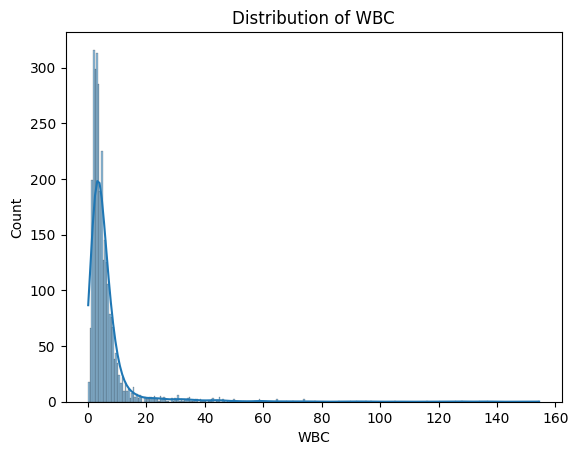

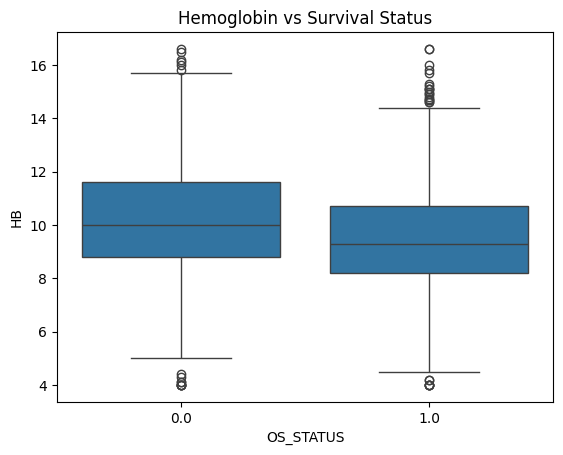

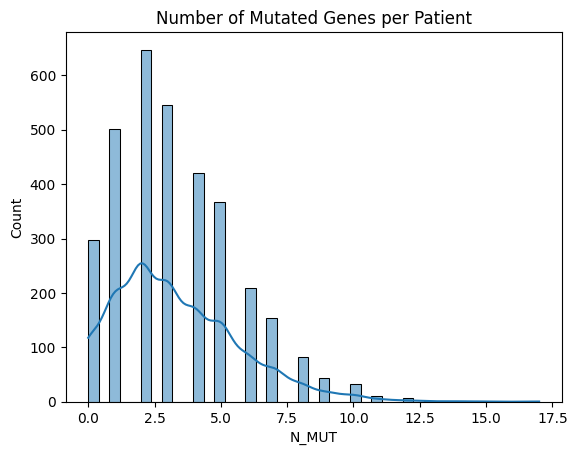

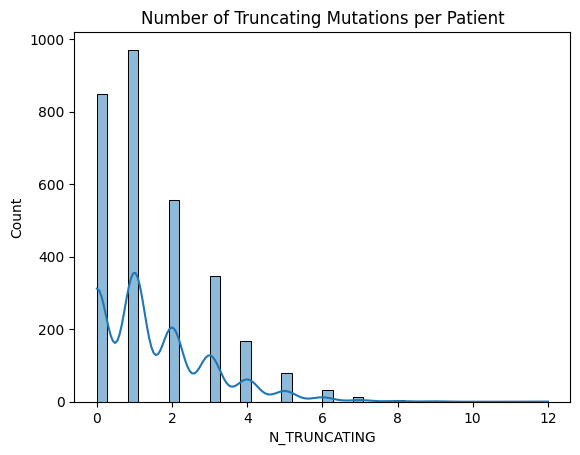

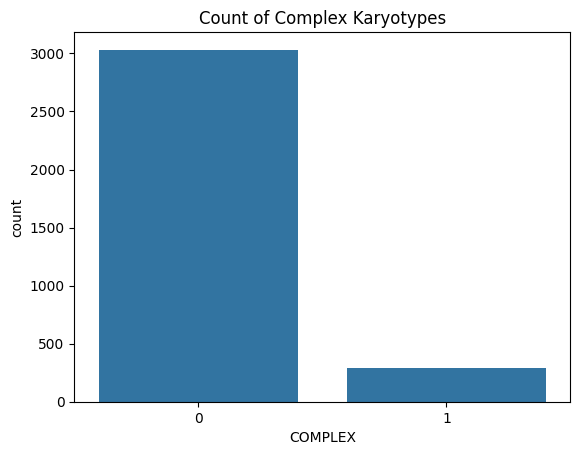

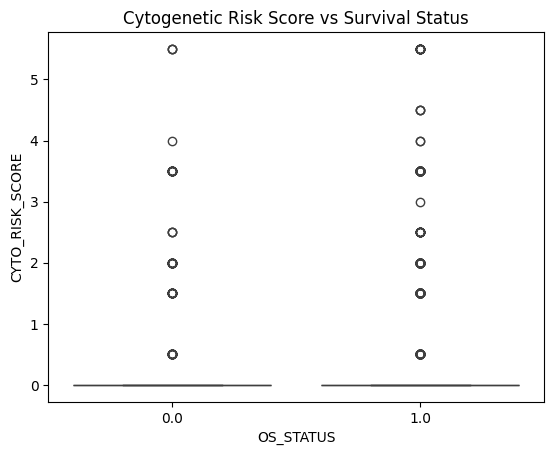

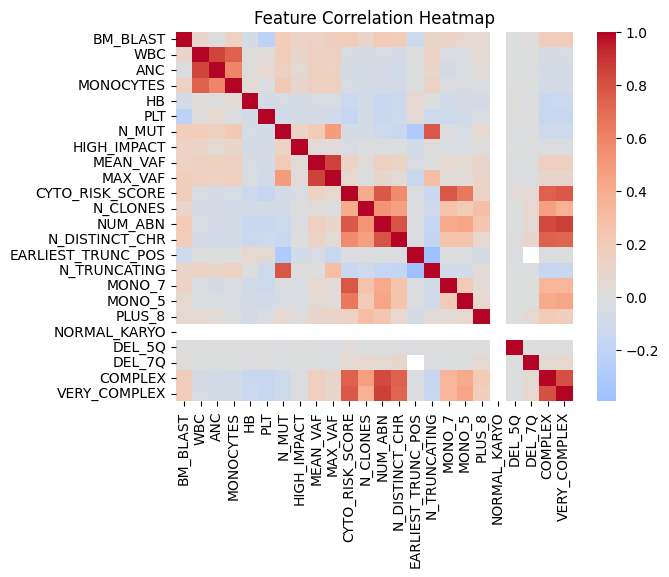

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Clinical feature distributions ---
sns.histplot(train_df['WBC'], kde=True)
plt.title("Distribution of WBC")
plt.show()

sns.boxplot(x='OS_STATUS', y='HB', data=target.merge(train_df, on='ID'))
plt.title("Hemoglobin vs Survival Status")
plt.show()

# --- Molecular features ---
sns.histplot(train_df['N_MUT'], kde=True)
plt.title("Number of Mutated Genes per Patient")
plt.show()

sns.histplot(train_df['N_TRUNCATING'], kde=True)
plt.title("Number of Truncating Mutations per Patient")
plt.show()

# --- Cytogenetic features ---
sns.countplot(x='COMPLEX', data=train_df)
plt.title("Count of Complex Karyotypes")
plt.show()

sns.boxplot(x='OS_STATUS', y='CYTO_RISK_SCORE', data=train_df.merge(target, on='ID'))
plt.title("Cytogenetic Risk Score vs Survival Status")
plt.show()

# --- Correlation heatmap ---
sns.heatmap(train_df[num_features + bin_features].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

- Impute missing values
- Scale numeric features (RobustScaler + MinMaxScaler)
- Pass binary features through without transformation
- Combine preprocessing with CoxPHSurvivalAnalysis for survival prediction.

In [140]:
pca = PCA(n_components=8,whiten=True,svd_solver='full')

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", RobustScaler()),
    ("Mmscaler", MinMaxScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("bin", "passthrough", bin_features),
])

model = CoxPHSurvivalAnalysis(alpha=1e-3,n_iter=100,ties='efron')

pipeline = Pipeline([
    ("prep", preprocess),
    ("cox", model)
])

Perform stratified K-fold cross-validation and calculate mean IPCW-concordance index.

In [141]:
kf = StratifiedKFold(n_splits=19, shuffle=True, random_state=42)
scores = []

X = train_df.set_index("ID").loc[target["ID"]]
y_array = target["OS_STATUS"].astype(int).values 

for train_idx, val_idx in kf.split(X, y_array): 
    X_tr = X.iloc[train_idx]
    X_va = X.iloc[val_idx]
    y_tr = y[train_idx]
    y_va = y[val_idx]

    pipeline.fit(X_tr, y_tr)
    risk_va = pipeline.predict(X_va)

    cindex = concordance_index_ipcw(
        y_tr, y_va, risk_va, tau=5
    )[0]
    scores.append(cindex)

print(f"Mean IPCW-C-index: {np.mean(scores):.4f}")
print(f"Std IPCW-C-index : {np.std(scores):.4f}")

Mean IPCW-C-index: 0.7169
Std IPCW-C-index : 0.0248


Extract model coefficients (beta) and hazard ratios to understand the contribution of each feature.

In [142]:
# Get fitted Cox model
cox_model = pipeline.named_steps["cox"]

# Get feature names after preprocessing
prep = pipeline.named_steps["prep"]

num_names = num_features
bin_names = bin_features

feature_names = np.concatenate([num_names, bin_names])

# Build coefficient table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "beta": cox_model.coef_,
    "hazard_ratio": np.exp(cox_model.coef_)
}).sort_values(by="beta", key=np.abs, ascending=False)

coef_df.head(15)

,feature,beta,hazard_ratio
6,N_MUT,2.359880,10.589682
5,PLT,-2.114909,0.120644
13,N_DISTINCT_CHR,2.051049,7.776051
4,HB,-1.853050,0.156758
0,BM_BLAST,1.772597,5.886119
14,EARLIEST_TRUNC_POS,-1.355376,0.257850
1,WBC,1.323363,3.756033
12,NUM_ABN,1.054149,2.869533
15,N_TRUNCATING,-0.636202,0.529299
11,N_CLONES,-0.557198,0.572812


We perform PCA on the numeric features to visualize the principal components and see how much each original feature contributes to the main components.

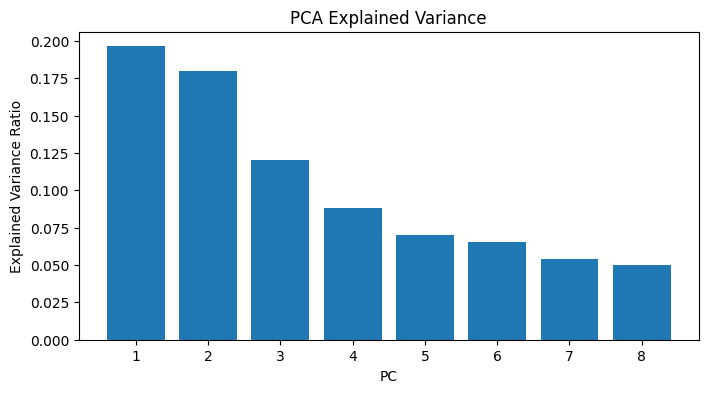

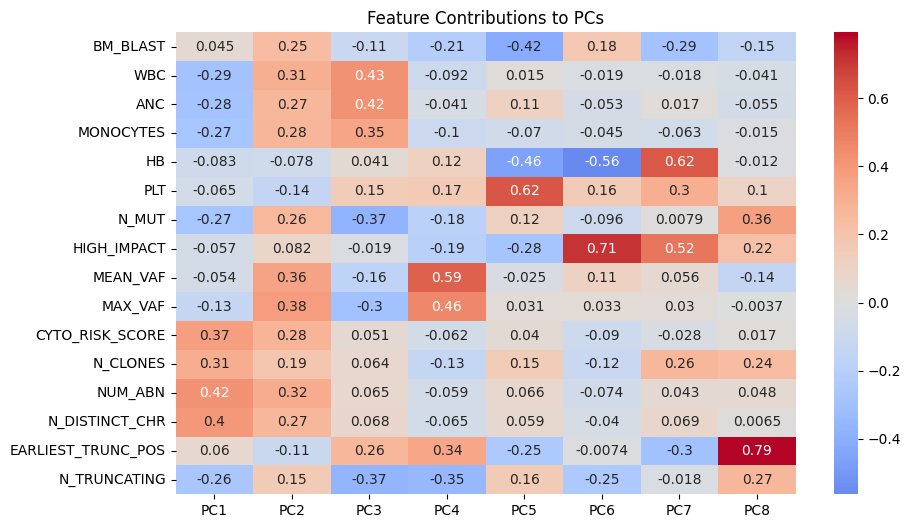

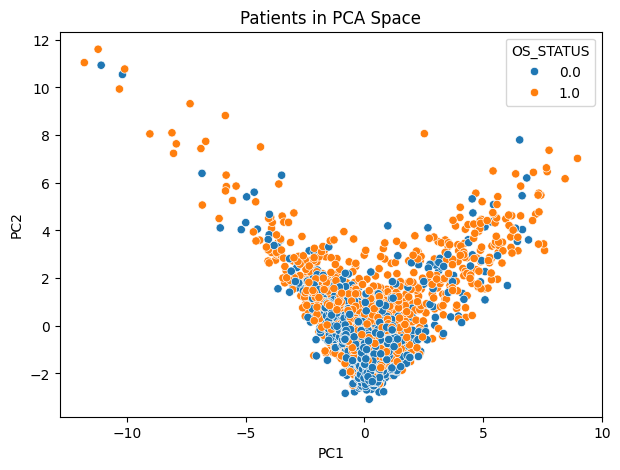

In [143]:
# Keep only patients with target
common_ids = train_df["ID"].isin(target["ID"])
X_numeric = train_df.loc[common_ids].set_index("ID")[num_features]

imputer = SimpleImputer(strategy="mean")
X_numeric_imputed = imputer.fit_transform(X_numeric)


# Fit PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=min(len(num_features), 8))
X_pca = pca.fit_transform(X_numeric_scaled)

# Explained variance
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

# Loadings heatmap
import seaborn as sns
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=num_features
)
plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Contributions to PCs")
plt.show()

# Scatter plot colored by OS_STATUS
y_status = target.set_index("ID").loc[X_numeric.index]["OS_STATUS"]
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_status)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patients in PCA Space")
plt.show()

Fit the pipeline on all training data and generate risk scores for the test dataset.
Save predictions to CSV.

In [144]:
pipeline.fit(X, y)

,steps,"[('prep', ...), ('cox', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [145]:
X_test = test_df.set_index("ID")
risk_test = pipeline.predict(X_test)

In [146]:
submission = pd.DataFrame(
    {"risk_score": risk_test},
    index=X_test.index
)
submission.to_csv("submission.csv")
submission.head()

,risk_score
ID,
KYW1,1.602045
KYW2,1.500731
KYW3,-0.408067
KYW4,1.192776
KYW5,0.759903
